# Geocalibration

Here we use the geocalibration data calculated from agisoft metashape using the OPK values. The fitting will be done for each focus positions and camera. We will use the $R^r_{r'}$ values fitted from the 034 and fit $R^m_{c,0}$ and $R^m_{c,1}$ for each left and right camera between focus positions 026-110.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import itertools
import plotly.express as px
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize

from typing import List

In [2]:
data_fpath = "../plots/m41_site_cal_v230_v3_20240809_165619.xlsx"
f_str = "034"

to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_mat = lambda x:np.array([[float(val.strip()) for val in r[1:].split(", ") if len(val)] for r in x[1:-2].split("], ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_comma)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_comma)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_comma)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_comma)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

  return z_data

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
    """
    Form the H matrix from the ground truth data
    """
    h_r = data_["h_r_vec"][idx]
    v_r = data_["v_r_vec"][idx]
    a_r = data_["a_r_vec"][idx]

    H_r = np.array([h_r, v_r, a_r]).T

    return H_r

# read in the data
data_all = pd.read_excel(data_fpath, index_col=0)
data_all = parse_cahvor(data_all)


In [4]:
f_str = "110"

zl_f = data_all[data_all["cam"]==f"ZL{f_str}"].copy().reset_index()
zr_f = data_all[data_all["cam"]==f"ZR{f_str}"].copy().reset_index()

fig = px.scatter(zl_f, x="fmc", y="f_est", hover_data="index", title=f"ZL{f_str}")
fig.show()


fig = px.scatter(zr_f, x="fmc", y="f_est", hover_data="index", title=f"ZR{f_str}")
fig.show()

In [36]:
# read in the data
data_all = pd.read_excel(data_fpath, index_col=0)
data_all = parse_cahvor(data_all)

# drop the outliers
drop_idxs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 286, 287, 288, 289, 290, 
            291, 292, 293, 294, 295, 296, 1298, 1434, 1582, 1583, 1584, 
            1585, 1674, 1675, 1676, 1677, 1679, 1680, 1738, 1739, 1740, 
            1741, 1742, 1831, 1831, 1832, 1833, 1834, 1836, 1860, 1861, 
            1885, 1886, 1887, 1889, 1894, 1896, 1898, 1910, 1911, 1912, 
            1913, 1914, 1915, 1926, 1927, 1928, 1929, 1930, 1931]
data_all.drop(axis=0, index=drop_idxs, inplace=True)
data_all.reset_index(inplace=True, drop=True)



# data structure to store the fits
f_strs = ['026', '034', '048', '063', '079', '110']
template = {"fl0":None, "fl1":None, 
          "rot_mc_0":None, "rot_mc_1":None,
          "lmbd_h":0.3, "lmbd_v":0.009, "lmbd_a":90}

params.update({f"ZL{f_str}":template.copy() for f_str in f_strs})
params.update({f"ZR{f_str}":template.copy() for f_str in f_strs})
params["rot_rrp"] = R.from_quat([0,0,0,1])

# Focal Length Fits

In [37]:
for f_str in f_strs:
    # split zl and zr data
    zl, zr = get_zl_zr(f_str, data_all)

    # Left Camera fl-fmc fits 
    X_l, Y_l = np.vstack([np.ones(zl.shape[0]), zl["fmc"]]).T , zl["f_est"]
    theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
    params[f"ZL{f_str}"]["fl0"], params[f"ZL{f_str}"]["fl1"] = theta_l
    print(f"[ZL{f_str}] fl = {theta_l[0]:.5f} + {theta_l[1]:.5f} * fmc")

    # Right Camera fl-fmc fits 
    X_r, Y_r = np.vstack([np.ones(zr.shape[0]), zr["fmc"]]).T , zr["f_est"]
    theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
    params[f"ZR{f_str}"]["fl0"], params[f"ZR{f_str}"]["fl1"] = theta_r
    print(f"[ZR{f_str}] fl = {theta_r[0]:.5f} + {theta_r[1]:.5f} * fmc")

[ZL026] fl = 3666.75546 + 0.05731 * fmc
[ZR026] fl = 3634.13753 + 0.05639 * fmc
[ZL034] fl = 4687.11755 + 0.04762 * fmc
[ZR034] fl = 4694.16501 + 0.04853 * fmc
[ZL048] fl = 6584.15500 + 0.03179 * fmc
[ZR048] fl = 6568.23333 + 0.03898 * fmc
[ZL063] fl = 8572.09566 + 0.01831 * fmc
[ZR063] fl = 8507.02982 + 0.04309 * fmc
[ZL079] fl = 10651.25196 + 0.04085 * fmc
[ZR079] fl = 10597.59162 + 0.05707 * fmc
[ZL110] fl = 14472.01658 + 0.12631 * fmc
[ZR110] fl = 14436.69607 + 0.13804 * fmc


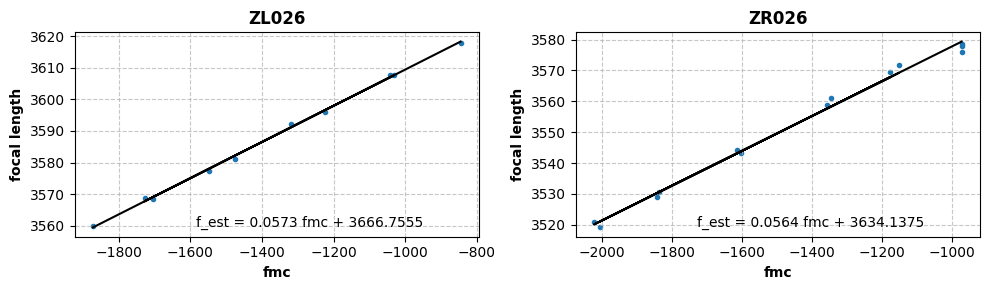

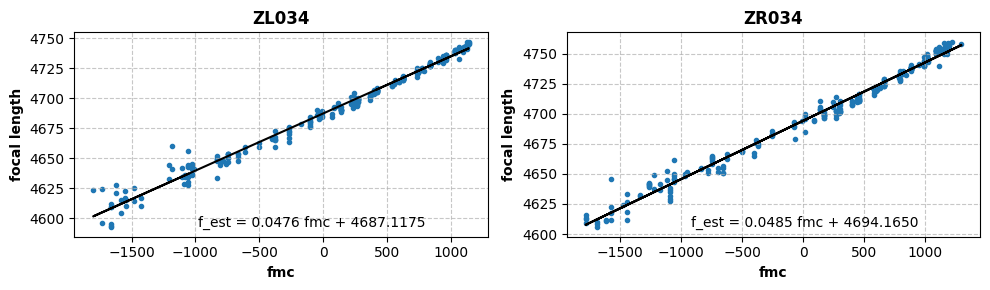

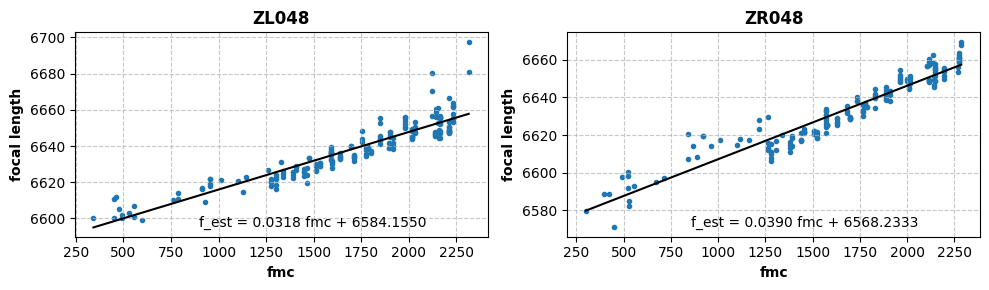

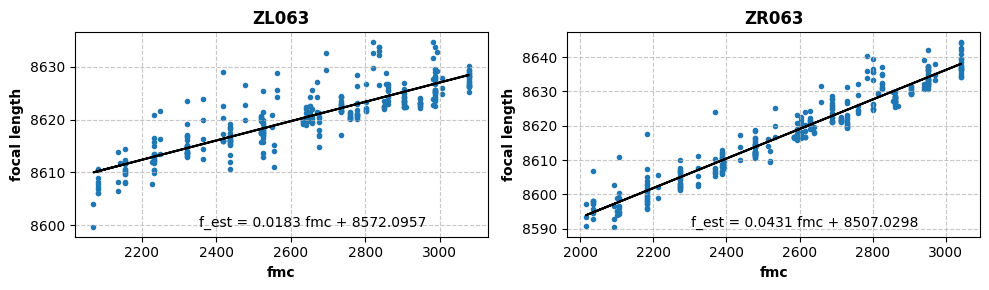

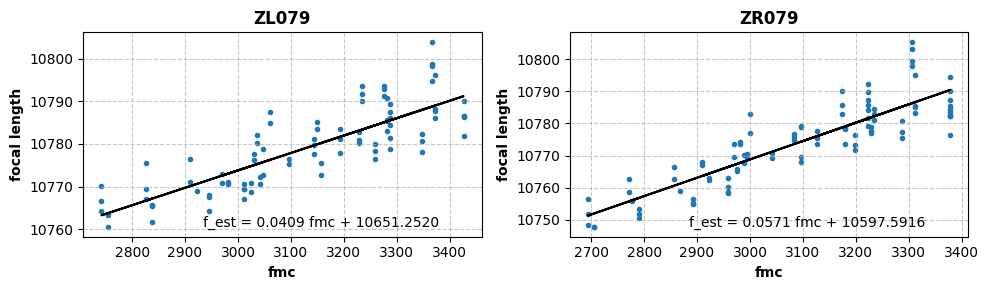

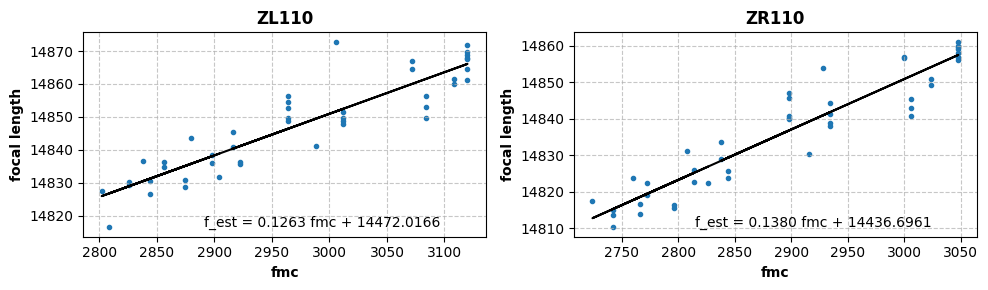

In [38]:
f_str = "026"

for f_str in f_strs:
        fig, ax = plt.subplots(1, 2, figsize=(10, 3))

        zl, zr = get_zl_zr(f_str, data_all)
        # ZL034 FL-FMC plots
        ax[0].scatter(zl["fmc"], zl["f_est"], marker='.')
        fl0_l, fl1_l = params[f"ZL{f_str}"]["fl0"], params[f"ZL{f_str}"]["fl1"]
        ax[0].plot(zl["fmc"], [fl0_l + fl1_l * f for f in zl["fmc"]],
                color="black")
        ax[0].grid(linestyle="--", alpha=0.7)
        ax[0].set_xlabel("fmc", fontweight="bold")
        ax[0].set_ylabel("focal length", fontweight="bold")
        ax[0].set_title(f"ZL{f_str}", fontweight="bold")
        ax[0].text(0.3, 0.05, "f_est = {:.4f} fmc + {:.4f}".format(fl1_l, fl0_l), transform=ax[0].transAxes)


        # ZR034 FL-FMC plots
        ax[1].scatter(zr["fmc"], zr["f_est"], marker='.')
        fl0_r, fl1_r = params[f"ZR{f_str}"]["fl0"], params[f"ZR{f_str}"]["fl1"]
        ax[1].plot(zr["fmc"], [fl0_r + fl1_r * f for f in zr["fmc"]],
                color="black")
        ax[1].grid(linestyle="--", alpha=0.7)
        ax[1].set_xlabel("fmc", fontweight="bold")
        ax[1].set_ylabel("focal length", fontweight="bold")
        ax[1].set_title(f"ZR{f_str}", fontweight="bold")
        ax[1].text(0.3, 0.05, "f_est = {:.4f} fmc + {:.4f}".format(fl1_r, fl0_r), transform=ax[1].transAxes)

        fig.tight_layout()

# Rotation Fitting

### Kabsch Fit

In [39]:

def solve_r_mc(data_, params_):
    data_ = data_.copy()
    params_ = params_.copy()
    R_rrp = params_["rot_rrp"].as_matrix()

    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_)

        # LEFT CAMERA FITS
        m_frame_l, c_frame_l = [], []
        for i in range(zl.shape[0]):
            # compute hm from hr
            Hr = get_H_r_data(i, zl)
            R_rpm = get_R_rpm(i, zl)
            Hm = (R_rrp @ R_rpm).T @ Hr
            m_frame_l.append(params[f"ZL{f_str}"]["lmbd_h"] * Hm[:, 0])
            m_frame_l.append(params[f"ZL{f_str}"]["lmbd_v"] * Hm[:, 1])
            m_frame_l.append(params[f"ZL{f_str}"]["lmbd_a"] * Hm[:, 2])

            # compute hc
            f, b1, b2, cx, cy = zl[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i, :]
            fl = params_[f"ZL{f_str}"]["fl0"] + params_[f"ZL{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            c_frame_l.append(params[f"ZL{f_str}"]["lmbd_h"] * Hc[:, 0])
            c_frame_l.append(params[f"ZL{f_str}"]["lmbd_v"] * Hc[:, 1])
            c_frame_l.append(params[f"ZL{f_str}"]["lmbd_a"] * Hc[:, 2])

        params_[f"ZL{f_str}"]["rot_mc_0"], _ = R.align_vectors(m_frame_l, c_frame_l, return_sensitivity=False)

        # RIGHT CAMERA FITS
        m_frame_r, c_frame_r = [], []
        for i in range(zr.shape[0]):
            # compute hm from hr
            Hr = get_H_r_data(i, zr)
            R_rpm = get_R_rpm(i, zr)
            Hm = (R_rrp @ R_rpm).T @ Hr
            m_frame_r.append(params[f"ZR{f_str}"]["lmbd_h"] * Hm[:, 0])
            m_frame_r.append(params[f"ZR{f_str}"]["lmbd_v"] * Hm[:, 1])
            m_frame_r.append(params[f"ZR{f_str}"]["lmbd_a"] * Hm[:, 2])

            # compute hc
            f, b1, b2, cx, cy = zr[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i, :]
            fl = params_[f"ZR{f_str}"]["fl0"] + params_[f"ZR{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            c_frame_r.append(params[f"ZR{f_str}"]["lmbd_h"] * Hc[:, 0])
            c_frame_r.append(params[f"ZR{f_str}"]["lmbd_v"] * Hc[:, 1])
            c_frame_r.append(params[f"ZR{f_str}"]["lmbd_a"] * Hc[:, 2])

        params_[f"ZR{f_str}"]["rot_mc_0"], _ = R.align_vectors(m_frame_r, c_frame_r, return_sensitivity=False)
    
    return params_

def solve_r_rrp(data_, params_):
    data_ = data_.copy()
    params_ = params_.copy()
    # solve for rrp
    r_frame, rp_frame = [], []

    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_all)

        # left camera
        R_mc_l = params_[f"ZL{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zl.shape[0]):
            # r frame vectors
            Hr = get_H_r_data(i, zl)
            r_frame.append(params_[f"ZL{f_str}"]["lmbd_h"] * Hr[:, 0])
            r_frame.append(params_[f"ZL{f_str}"]["lmbd_v"] * Hr[:, 1])
            r_frame.append(params_[f"ZL{f_str}"]["lmbd_a"] * Hr[:, 2])

            # r' frame vectors
            R_rpm = get_R_rpm(i, zl)
            f, b1, b2, cx, cy = zl[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
            fl = params_[f"ZL{f_str}"]["fl0"] + params_[f"ZL{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hrp = R_rpm @ R_mc_l @ Hc
            rp_frame.append(params_[f"ZL{f_str}"]["lmbd_h"] * Hrp[:, 0])
            rp_frame.append(params_[f"ZL{f_str}"]["lmbd_v"] * Hrp[:, 1])
            rp_frame.append(params_[f"ZL{f_str}"]["lmbd_a"] * Hrp[:, 2])

        # right camera
        R_mc_r = params_[f"ZR{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zr.shape[0]):
            # r frame vectors
            Hr = get_H_r_data(i, zr)
            r_frame.append(params_[f"ZR{f_str}"]["lmbd_h"] * Hr[:, 0])
            r_frame.append(params_[f"ZR{f_str}"]["lmbd_v"] * Hr[:, 1])
            r_frame.append(params_[f"ZR{f_str}"]["lmbd_a"] * Hr[:, 2])

            # r' frame vectors
            R_rpm = get_R_rpm(i, zr)
            f, b1, b2, cx, cy = zr[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
            fl = params_[f"ZR{f_str}"]["fl0"] + params_[f"ZR{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hrp = R_rpm @ R_mc_l @ Hc
            rp_frame.append(params_[f"ZR{f_str}"]["lmbd_h"] * Hrp[:, 0])
            rp_frame.append(params_[f"ZR{f_str}"]["lmbd_v"] * Hrp[:, 1])
            rp_frame.append(params_[f"ZR{f_str}"]["lmbd_a"] * Hrp[:, 2])

    params_["rot_rrp"], _ = R.align_vectors(r_frame, rp_frame, return_sensitivity=False)
    return params_
    
def calc_total_rel_error(data_, params_):
    # compute the relative error
    data_ = data_.copy()
    params_ = params_.copy()

    R_rrp = params["rot_rrp"].as_matrix()
    tot_rel_err = 0
    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_)

        # left camera errors
        R_mc_l = params_[f"ZL{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zl.shape[0]):
            Hr_data = get_H_r_data(i, zl)

            R_rpm = get_R_rpm(i, zl)
            f, b1, b2, cx, cy = zl[["fmc", "b1", "b2", "cx", "cy"]].iloc[i, :]
            fl = params_[f"ZL{f_str}"]["fl0"] + params_[f"ZL{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hr_model = R_rrp @ R_rpm @ R_mc_l @ Hc

            tot_rel_err = np.linalg.norm(Hr_data[:, 0] - Hr_model[:, 0])/np.linalg.norm(Hr_data[:, 0])
            tot_rel_err = np.linalg.norm(Hr_data[:, 1] - Hr_model[:, 1])/np.linalg.norm(Hr_data[:, 1])
            tot_rel_err = np.linalg.norm(Hr_data[:, 2] - Hr_model[:, 2])/np.linalg.norm(Hr_data[:, 2])


        # right camera errors
        R_mc_r = params_[f"ZR{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zr.shape[0]):
            Hr_data = get_H_r_data(i, zr)

            R_rpm = get_R_rpm(i, zr)
            f, b1, b2, cx, cy = zr[["fmc", "b1", "b2", "cx", "cy"]].iloc[i, :]
            fl = params_[f"ZR{f_str}"]["fl0"] + params_[f"ZR{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hr_model = R_rrp @ R_rpm @ R_mc_r @ Hc

            tot_rel_err = np.linalg.norm(Hr_data[:, 0] - Hr_model[:, 0])/np.linalg.norm(Hr_data[:, 0])
            tot_rel_err = np.linalg.norm(Hr_data[:, 1] - Hr_model[:, 1])/np.linalg.norm(Hr_data[:, 1])
            tot_rel_err = np.linalg.norm(Hr_data[:, 2] - Hr_model[:, 2])/np.linalg.norm(Hr_data[:, 2])
    
    return tot_rel_err

def kabsch_fit(data_, params_, verbosity=False, niters=250, verbose=25, eps=1e-6):
    data_ = data_.copy()
    params_ = params_.copy()

    total_rel_err = 0
    for i in range(niters):
        params_ = solve_r_mc(data_, params_)
        params_ = solve_r_rrp(data_, params_)
        total_rel_err_new = calc_total_rel_error(data_, params)

        # if change in relative error is small, break the loop
        if abs(total_rel_err - total_rel_err_new) < eps:
            if verbosity:
                print(f"Iteration {i}")
                print(f"Total Relative Error: {total_rel_err:.8f}")
                for f_str in f_strs:
                    print(f"[ZL{f_str}] q_mc: {params_[f'ZL{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
                    print(f"[ZR{f_str}] q_mc: {params_[f'ZR{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
                print(f"q_rrp: {params_['rot_rrp'].as_quat(canonical=True)}")
            break
        total_rel_err = total_rel_err_new

        # print for verbosity
        if verbosity and ((i%verbose == 0 and i>0) or (i == niters-1)):
            print(f"Iteration {i}")
            print(f"Total Relative Error: {total_rel_err:.8f}")
            for f_str in f_strs:
                print(f"[ZL{f_str}] q_mc: {params_[f'ZL{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
                print(f"[ZR{f_str}] q_mc: {params_[f'ZR{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
            print(f"q_rrp: {params_['rot_rrp'].as_quat(canonical=True)}")
            print("="*150)

    return params_


In [40]:
params = kabsch_fit(data_all, params, verbosity=True)

Iteration 25
Total Relative Error: 0.21959115
[ZL026] q_mc: [0.45384604 0.52539759 0.57701327 0.43015907]
[ZR026] q_mc: [0.46017451 0.52092834 0.56522422 0.44429121]
[ZL034] q_mc: [0.47195257 0.50925154 0.58070989 0.42508782]
[ZR034] q_mc: [0.4850695  0.49765942 0.57254415 0.4350125 ]
[ZL048] q_mc: [0.45528744 0.53436937 0.57514374 0.41996713]
[ZR048] q_mc: [0.47098778 0.52072818 0.56756651 0.42997782]
[ZL063] q_mc: [0.45603904 0.52996131 0.57428475 0.42587139]
[ZR063] q_mc: [0.47027476 0.51610748 0.56794983 0.43578402]
[ZL079] q_mc: [0.44402308 0.54340854 0.56816493 0.42981308]
[ZR079] q_mc: [0.45863307 0.53401352 0.55934616 0.43774094]
[ZL110] q_mc: [0.45486163 0.54370913 0.56698012 0.41954121]
[ZR110] q_mc: [0.47002083 0.53353962 0.55883898 0.4267492 ]
q_rrp: [ 0.00726891  0.00879594 -0.11452559  0.99335476]
Iteration 50
Total Relative Error: 0.26464554
[ZL026] q_mc: [0.44612392 0.52857804 0.59106236 0.41499878]
[ZR026] q_mc: [0.45104716 0.52606861 0.57856569 0.43019765]
[ZL034] q_m

Text(0.5, 0.98, '$H^r$ for ZL034 Iterative Kabsch Fit')

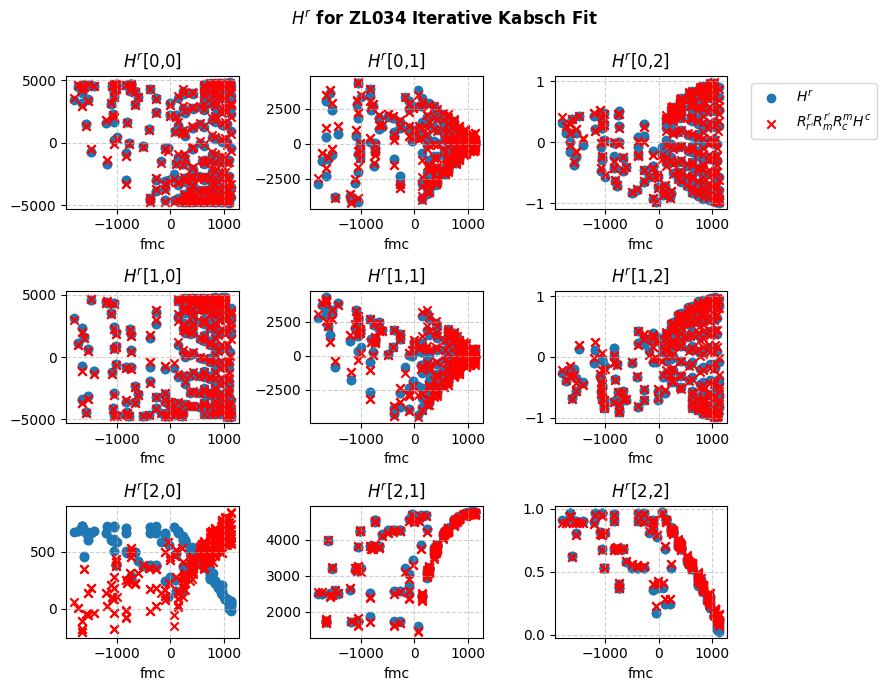

In [43]:
def plot_hr(data_, rot_rrp, rot_mc, fl0, fl1):
  hr_data_left, hr_model_left = [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle(f"$H^r$ plot", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

zl34 = data_all[data_all["cam"]=="ZL034"].reset_index(drop=True)
fig, ax = plot_hr(zl34, rot_rrp=params["rot_rrp"], rot_mc=params["ZL034"]["rot_mc_0"],
              fl0=params["ZL034"]["fl0"], fl1=params["ZL034"]["fl1"])
fig.suptitle("$H^r$ for ZL034 Iterative Kabsch Fit", fontweight="bold", fontsize=12)

Text(0.5, 0.98, '$H^r$ for ZL034 Iterative Kabsch Fit')

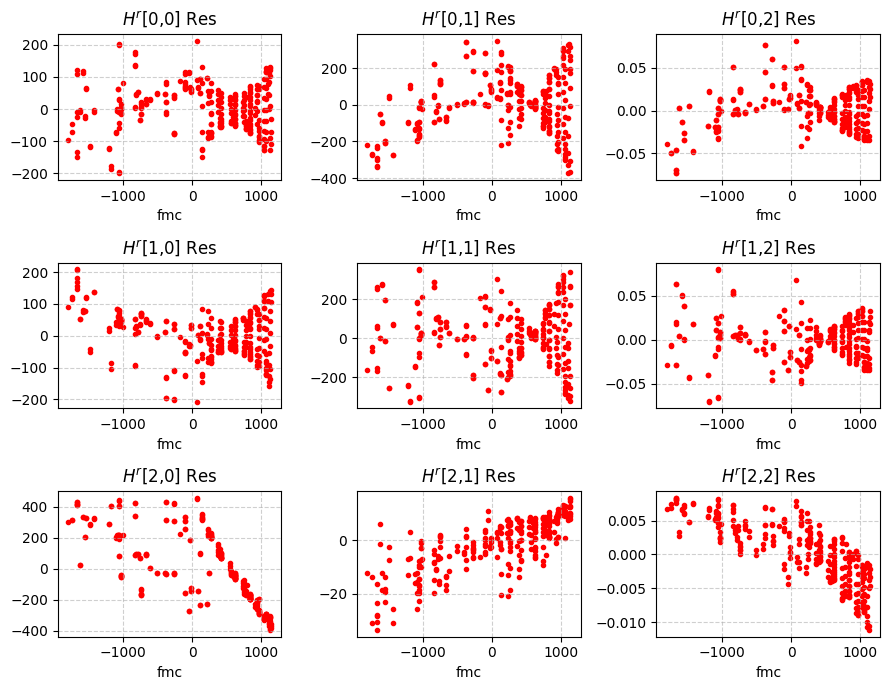

In [11]:
def plot_hr_res(data_, rot_rrp, rot_mc, fl0, fl1):
  hr_res = []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr = get_H_r_data(i, data_)

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    
    # compute res
    hr_res.append(Hr - R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_res],
                      marker='.', color='red')
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}] Res")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.tight_layout()

  return fig, ax

plot_hr_res(zl34, rot_rrp=params["rot_rrp"], rot_mc=params["ZL034"]["rot_mc_0"],
              fl0=params["ZL034"]["fl0"], fl1=params["ZL034"]["fl1"])
fig.suptitle("$H^r$ for ZL034 Iterative Kabsch Fit", fontweight="bold", fontsize=12)

Next, we use the rotations that were found by the iterative kabsch algorithm as an initial guess for BFGS fits. 

In [56]:
def obj(x):
    # objective function value
    R_rrp = R.from_quat(x[:4]).as_matrix()

    total_cost = 0
    for i, f_str in enumerate(f_strs):
        strt_idx = 4 + i * 16
        rot_mc_l_0 = R.from_quat(x[strt_idx : strt_idx+4])
        rot_mc_l_1 = R.from_quat(x[strt_idx+4 : strt_idx+8])
        rot_mc_r_0 = R.from_quat(x[strt_idx+8 : strt_idx+12])
        rot_mc_r_1 = R.from_quat(x[strt_idx+12 : strt_idx+16])

        zl, zr = get_zl_zr(f_str, data_all)

        # left camera
        for i in range(zl.shape[0]):
            # H^r matrix
            Hr = get_H_r_data(i, zl)

            # H^c matrix
            f, b1, b2, cx, cy = zl[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
            cam = zl["cam"].iloc[i]
            fl = params[f"ZL{f_str}"]["fl0"] + params[f"ZL{f_str}"]["fl1"] * f
            Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]

            # rotation matrices
            R_rpm = get_R_rpm(i, zl)
            R_mc = (rot_mc_l_0 * (rot_mc_l_1**(f/1000))).as_matrix()

            # Errors
            err = (Hr - R_rrp @ R_rpm @ R_mc @ Hc)
            total_cost += np.linalg.norm(err[:,0])**2 / np.linalg.norm(Hr[:,0])**2
            total_cost += np.linalg.norm(err[:,1])**2 / np.linalg.norm(Hr[:,1])**2
            total_cost += np.linalg.norm(err[:,2])**2 / np.linalg.norm(Hr[:,2])**2

        # right camera
        for i in range(zr.shape[0]):
            # H^r matrix
            Hr = get_H_r_data(i, zr)

            # H^c matrix
            f, b1, b2, cx, cy = zr[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
            cam = zr["cam"].iloc[i]
            fl = params[f"ZR{f_str}"]["fl0"] + params[f"ZR{f_str}"]["fl1"] * f
            Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]

            # rotation matrices
            R_rpm = get_R_rpm(i, zr)
            R_mc = (rot_mc_r_0 * (rot_mc_r_1**(f/1000))).as_matrix()

            # Errors
            err = (Hr - R_rrp @ R_rpm @ R_mc @ Hc)
            total_cost += np.linalg.norm(err[:,0])**2 / np.linalg.norm(Hr[:,0])**2
            total_cost += np.linalg.norm(err[:,1])**2 / np.linalg.norm(Hr[:,1])**2
            total_cost += np.linalg.norm(err[:,2])**2 / np.linalg.norm(Hr[:,2])**2        

    return total_cost

# initial values for BFGS
x0 = list(params["rot_rrp"].as_quat(canonical=True))
for f_str in f_strs:
    x0 += list(params[f"ZL{f_str}"]["rot_mc_0"].as_quat(canonical=True))
    x0 += [0,0,0,1]
    x0 += list(params[f"ZR{f_str}"]["rot_mc_0"].as_quat(canonical=True))
    x0 += [0,0,0,1]

# Run BFGS algorhthm
res = minimize(obj, x0, method="BFGS",
        options={"gtol":1e-6, "xrtol":1e-6, "maxiter":1})

# print results
print(f"q_rrp: {list(res.x[:4])}")
for i, f_str in enumerate(f_strs):
    strt_idx =  4 + i * 16

    print(f"[ZL{f_str}] q_mc_0: {list(res.x[strt_idx:strt_idx+4])}")
    print(f"[ZL{f_str}] q_mc_1: {list(res.x[strt_idx+4:strt_idx+8])}")
    print(f"[ZR{f_str}] q_mc_0: {list(res.x[strt_idx+8:strt_idx+12])}")
    print(f"[ZR{f_str}] q_mc_1: {list(res.x[strt_idx+12:strt_idx+16])}")

In [64]:
temps = {"fl0":None, "fl1":None, "q_mc_0":None, "q_mc_1":None}
params_save = {f"ZL{f_str}":temps.copy() for f_str in f_strs}
params_save.update({f"ZR{f_str}":temps.copy() for f_str in f_strs})
params_save["q_rrp"] = list(R.from_quat(res.x[:4]).as_quat(canonical=True))
params_save["t_rrp"] = [0, 0, 0]

for i, f_str in enumerate(f_strs):
    strt_idx =  4 + i * 16
    params_save[f"ZL{f_str}"]["fl0"], params_save[f"ZL{f_str}"]["fl1"] = params[f"ZL{f_str}"]["fl0"], params[f"ZL{f_str}"]["fl1"]  
    params_save[f"ZL{f_str}"]["q_mc_0"] = list(R.from_quat(res.x[strt_idx:strt_idx+4]).as_quat(canonical=True))
    params_save[f"ZL{f_str}"]["q_mc_1"] = list(R.from_quat(res.x[strt_idx+4:strt_idx+8]).as_quat(canonical=True))
    params_save[f"ZL{f_str}"]["t_mc_0"] = [0, 0, 0]
    params_save[f"ZL{f_str}"]["t_mc_1"] = [0, 0, 0]

    params_save[f"ZR{f_str}"]["fl0"], params_save[f"ZR{f_str}"]["fl1"] = params[f"ZR{f_str}"]["fl0"], params[f"ZR{f_str}"]["fl1"]  
    params_save[f"ZR{f_str}"]["q_mc_0"] = list(R.from_quat(res.x[strt_idx+8:strt_idx+12]).as_quat(canonical=True))
    params_save[f"ZR{f_str}"]["q_mc_1"] = list(R.from_quat(res.x[strt_idx+12:strt_idx+16]).as_quat(canonical=True))
    params_save[f"ZR{f_str}"]["t_mc_0"] = [0, 0, 0]
    params_save[f"ZR{f_str}"]["t_mc_1"] = [0, 0, 0]

with open("Fits_v3.json", 'w+') as f:
    json.dump(params_save, f, indent=3)

params = params_save

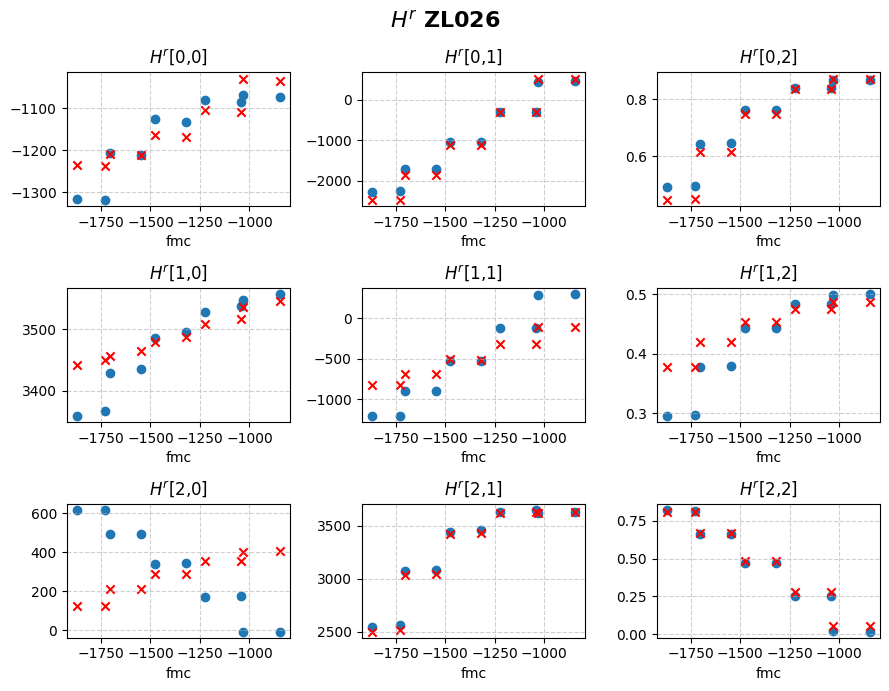

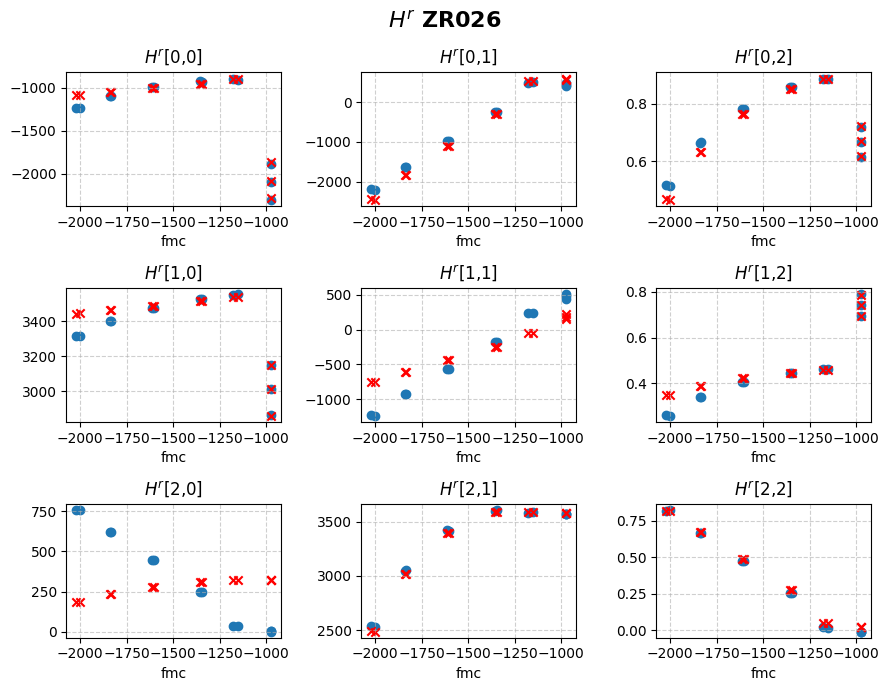

In [69]:
def plot_qmc_hr(data_, q_rrp, q_mc_0, q_mc_1, fl0, fl1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_data_left, hr_model_left = [], []


  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ {data_['cam'].iloc[0]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

f_str = "026"
zl34 = data_all[data_all["cam"]==f"ZL{f_str}"].reset_index(drop=True)
zr34 = data_all[data_all["cam"]==f"ZR{f_str}"].reset_index(drop=True)

fig, ax = plot_qmc_hr(zl34, q_rrp=params["q_rrp"], 
              q_mc_0 = params[f"ZL{f_str}"]["q_mc_0"], q_mc_1 = params[f"ZL{f_str}"]["q_mc_1"],
              fl0=params[f"ZL{f_str}"]["fl0"], fl1=params[f"ZL{f_str}"]["fl1"])

fig, ax = plot_qmc_hr(zr34, q_rrp=params["q_rrp"], 
              q_mc_0 = params[f"ZR{f_str}"]["q_mc_0"], q_mc_1 = params[f"ZR{f_str}"]["q_mc_1"],
              fl0=params[f"ZR{f_str}"]["fl0"], fl1=params[f"ZR{f_str}"]["fl1"])

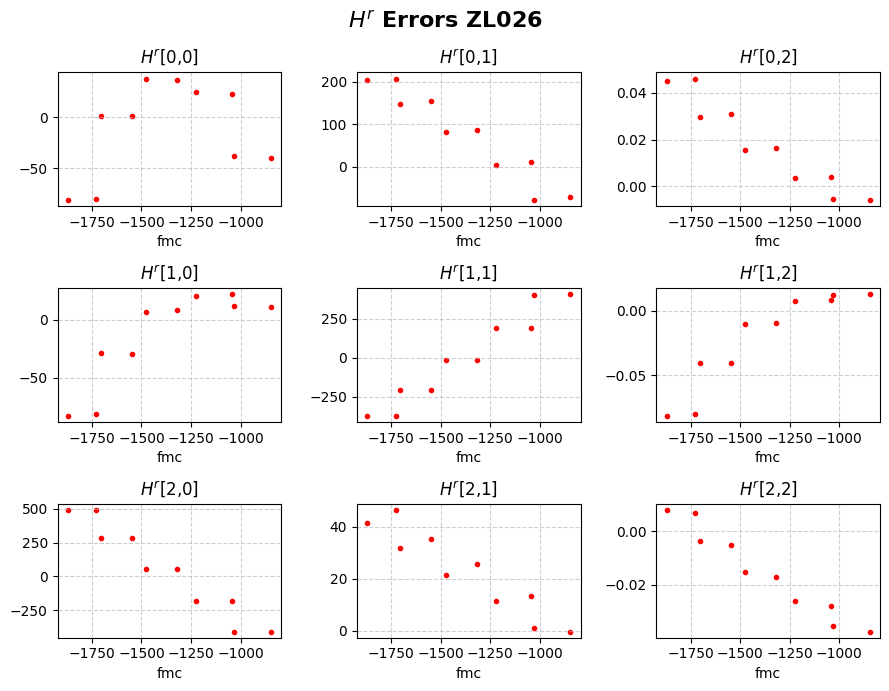

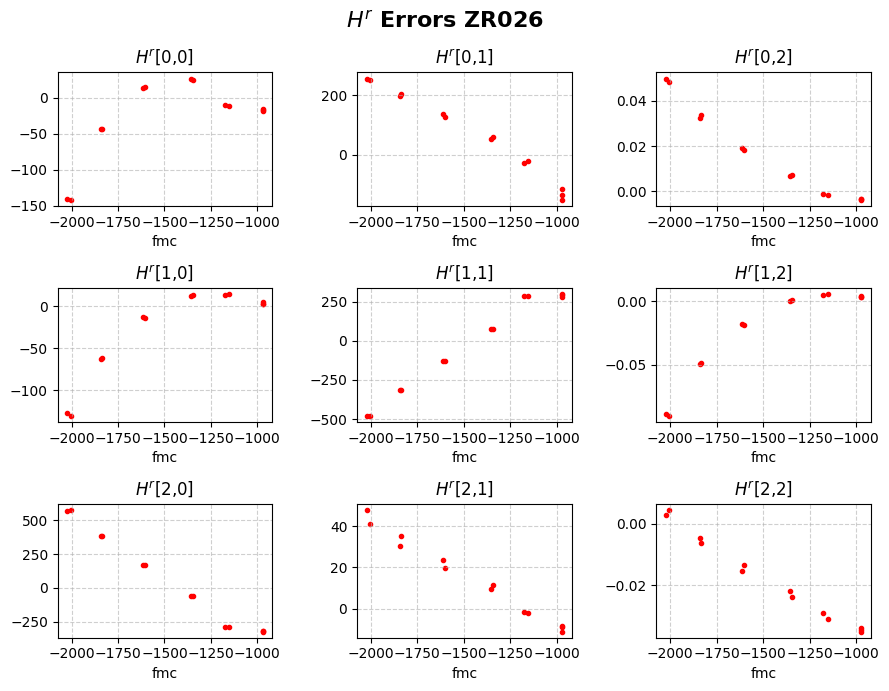

In [70]:
def plot_qmc_hr_err(data_, q_rrp, q_mc_0, q_mc_1, fl0, fl1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_err = []


  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    Hr_model = R_rrp @ R_rpm @ R_mc @ Hc

    hr_err.append(Hr_data - Hr_model)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_err], 
                      marker=".", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ Errors {data_['cam'].iloc[0]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax


f_str = "026"
zl34 = data_all[data_all["cam"]==f"ZL{f_str}"].reset_index(drop=True)
zr34 = data_all[data_all["cam"]==f"ZR{f_str}"].reset_index(drop=True)

fig, ax = plot_qmc_hr_err(zl34, q_rrp=params["q_rrp"], 
              q_mc_0 = params[f"ZL{f_str}"]["q_mc_0"], q_mc_1 = params[f"ZL{f_str}"]["q_mc_1"],
              fl0=params[f"ZL{f_str}"]["fl0"], fl1=params[f"ZL{f_str}"]["fl1"])

fig, ax = plot_qmc_hr_err(zr34, q_rrp=params["q_rrp"], 
              q_mc_0 = params[f"ZR{f_str}"]["q_mc_0"], q_mc_1 = params[f"ZR{f_str}"]["q_mc_1"],
              fl0=params[f"ZR{f_str}"]["fl0"], fl1=params[f"ZR{f_str}"]["fl1"])